# 1. The Single Crane Lift Sequence Problem

## Tier 3 — Genetic Algorithm (GA) for near-optimal sequencing

When the search space is huge, metaheuristics can find strong solutions without guaranteeing optimality.

This notebook implements a **small, readable GA from scratch** (no black-box optimizer).

### Learning goals

- Understand the GA loop: initialize → evaluate → select → crossover → mutate → repeat
- See how a "chromosome" (an ordering) can be evaluated by simulating crane operations
- Interpret convergence curves (what "improvement" looks like over generations)

### What you get

- The best-found ordering
- The implied lift plan (single/dual)
- Convergence plots + a path visualization


In [1]:
# Environment check (no installs here)
#
# Best practice for classes: preinstall dependencies in the Docker/JupyterHub image.
# If you're running locally, install packages once in your environment.

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        "Missing dependency. Install: numpy, pandas, matplotlib. "
        "If you use the provided JupyterHub Docker image, these should already be installed."
    ) from e

rng = np.random.default_rng(42)
print("Dependencies imported successfully.")


Dependencies imported successfully.


In [2]:
# ----------------------------
# Imports + data definition (Tier 3)
# ----------------------------
# Tier 3 uses a genetic algorithm (GA).
# Before we can run a GA we need:
# - a way to represent the data (containers)
# - a way to evaluate an ordering (objective function)

from dataclasses import dataclass
from typing import List, Tuple, Dict, Any


# ----------------------------
# Container representation
# ----------------------------
# `rc` is the (row, col) position in a 2x4 grid.
@dataclass(frozen=True)
class Container:
    id: int
    rc: Tuple[int, int]
    weight: float
    priority: int


# Same 8-container instance as Tier 2
containers = [
    Container(1, (0, 0), 8.5, 3),
    Container(2, (0, 1), 12.3, 2),
    Container(3, (0, 2), 15.7, 4),
    Container(4, (0, 3), 9.8, 3),
    Container(5, (1, 0), 11.2, 2),
    Container(6, (1, 1), 14.1, 2),
    Container(7, (1, 2), 13.9, 1),
    Container(8, (1, 3), 10.6, 2),
]

id_to_container = {c.id: c for c in containers}


# ----------------------------
# Parameters (minutes)
# ----------------------------
HANDLE_SINGLE = 2.5
HANDLE_DUAL = 3.8
SETUP_TIME = 1.2
DUAL_WEIGHT_LIMIT = 20.0
TRAVEL_PER_GRID_STEP = 0.8

START_RC = (0.0, 0.0)
START_MODE = "single"


# ----------------------------
# Helper functions
# ----------------------------
# Manhattan distance on a grid.
def manhattan(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# Two cells are adjacent if they share an edge.
def adjacent_int(a: Tuple[int, int], b: Tuple[int, int]) -> bool:
    return abs(a[0] - b[0]) + abs(a[1] - b[1]) == 1


# Dual feasibility: adjacent + weight <= limit.
def dual_feasible(i: int, j: int) -> bool:
    ci, cj = id_to_container[i], id_to_container[j]
    return adjacent_int(ci.rc, cj.rc) and (ci.weight + cj.weight) <= DUAL_WEIGHT_LIMIT


# Center point used for a dual lift.
def center(ci: Container, cj: Container) -> Tuple[float, float]:
    return ((ci.rc[0] + cj.rc[0]) / 2.0, (ci.rc[1] + cj.rc[1]) / 2.0)


# ----------------------------
# Objective function (simulation)
# ----------------------------
# A GA needs an objective function to tell it what is "good".
# Here, a chromosome is a permutation (ordering) of container IDs.
# We simulate the crane, moving along the order.
#
# Important: This simulation is simplified and deterministic. That's good for learning.

def evaluate_order(order: List[int]) -> Tuple[float, List[Dict[str, Any]]]:
    """Return (total_time, plan) for a proposed container ordering."""

    total = 0.0

    # Crane state
    rc = START_RC
    mode = START_MODE

    plan: List[Dict[str, Any]] = []

    # We walk through the permutation with index i.
    i = 0
    while i < len(order):
        cid = order[i]

        # If the next container exists and forms a feasible dual pair,
        # we lift both at once.
        if i + 1 < len(order) and dual_feasible(order[i], order[i + 1]):
            a, b = order[i], order[i + 1]
            ca, cb = id_to_container[a], id_to_container[b]

            # Travel target = center
            ctr = center(ca, cb)

            # Cost components
            travel = TRAVEL_PER_GRID_STEP * manhattan(rc, ctr)
            setup = SETUP_TIME if mode != "dual" else 0.0
            step = travel + setup + HANDLE_DUAL

            # Update totals + state
            total += step
            plan.append({"type": "dual", "containers": [a, b], "to": ctr, "step_time": step})
            rc = ctr
            mode = "dual"
            i += 2

        else:
            # Otherwise: single lift.
            c = id_to_container[cid]
            target = (float(c.rc[0]), float(c.rc[1]))

            travel = TRAVEL_PER_GRID_STEP * manhattan(rc, target)
            setup = SETUP_TIME if mode != "single" else 0.0
            step = travel + setup + HANDLE_SINGLE

            total += step
            plan.append({"type": "single", "containers": [cid], "to": target, "step_time": step})
            rc = target
            mode = "single"
            i += 1

    # Optional: a small penalty to encourage lifting higher priority earlier.
    # This is NOT a hard constraint; it just nudges the GA.
    for k, gene in enumerate(plan):
        for cid2 in gene["containers"]:
            prio = id_to_container[cid2].priority
            # Higher priority => smaller penalty
            total += 0.05 * (4 - prio) * (k / max(1, len(plan) - 1))

    return float(total), plan


# Quick sanity check: evaluate a simple ordering.
v0, _ = evaluate_order(list(range(1, 9)))
v0

28.39285714285715

## Genetic Algorithm (GA)

We use three standard ingredients:

- **Selection** (tournament): prefer better solutions but keep diversity
- **Crossover** (order crossover): combine two parent permutations
- **Mutation** (swap): inject randomness to escape local optima

### What the GA is optimizing

The GA minimizes the simulated completion time produced by `evaluate_order(order)`.

- Lower objective value is better.
- The objective includes travel, handling, setup time, and a small priority penalty.


In [3]:
# ----------------------------
# Genetic Algorithm (GA) operators
# ----------------------------
# We implement the GA from scratch in a readable way.
#
# Terminology:
# - A *chromosome* is a permutation (an ordering) of container IDs.
# - A *population* is a list of chromosomes.
# - Fitness here is *lower is better* (because we minimize total time).


def tournament_select(pop: List[List[int]], k: int = 3) -> List[int]:
    """Pick 1 parent using tournament selection.

    We randomly pick `k` individuals and return the best one.
    This keeps pressure toward better solutions while maintaining diversity.
    """

    idx = rng.choice(len(pop), size=k, replace=False)

    best = None
    best_val = float("inf")

    for i in idx:
        v, _ = evaluate_order(pop[i])
        if v < best_val:
            best_val = v
            best = pop[i]

    assert best is not None
    return best


def order_crossover(p1: List[int], p2: List[int]) -> List[int]:
    """Order crossover (OX) for permutations.

    Steps (simplified explanation):
    1) copy a slice from parent 1
    2) fill the remaining positions using parent 2 in order
    """

    n = len(p1)

    # Random slice boundaries
    a, b = sorted(rng.choice(n, size=2, replace=False))

    # -1 means "empty" for now
    child = [-1] * n

    # Copy slice from p1
    child[a:b] = p1[a:b]

    # Fill remaining slots with genes from p2 that are not yet used
    fill = [g for g in p2 if g not in child]

    ptr = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[ptr]
            ptr += 1

    return child


def mutate_swap(order: List[int], rate: float = 0.15) -> List[int]:
    """Swap mutation: with probability `rate`, swap two random positions."""

    if rng.random() < rate:
        i, j = rng.choice(len(order), size=2, replace=False)
        order = order.copy()
        order[i], order[j] = order[j], order[i]

    return order


def run_ga(
    pop_size: int = 40,
    generations: int = 120,
    elite: int = 4,
    crossover_rate: float = 0.8,
    mutation_rate: float = 0.15,
):
    """Run the GA and return the best solution + history."""

    # Base chromosome: [1,2,3,4,5,6,7,8]
    base = list(range(1, 9))

    # Initial population: random permutations
    pop = [rng.permutation(base).tolist() for _ in range(pop_size)]

    best_val = float("inf")
    best_order = None
    history = []

    for gen in range(generations):
        # Evaluate population (objective values)
        scored = [(evaluate_order(ind)[0], ind) for ind in pop]
        scored.sort(key=lambda x: x[0])

        # Update global best
        if scored[0][0] < best_val:
            best_val = scored[0][0]
            best_order = scored[0][1]

        history.append(best_val)

        # Elitism: keep the best few solutions unchanged
        new_pop = [ind for (_, ind) in scored[:elite]]

        # Fill the rest of the population
        while len(new_pop) < pop_size:
            # Select parents
            p1 = tournament_select(pop)
            p2 = tournament_select(pop)

            # Crossover or copy
            if rng.random() < crossover_rate:
                c1 = order_crossover(p1, p2)
                c2 = order_crossover(p2, p1)
            else:
                c1, c2 = p1.copy(), p2.copy()

            # Mutation
            c1 = mutate_swap(c1, rate=mutation_rate)
            c2 = mutate_swap(c2, rate=mutation_rate)

            new_pop.extend([c1, c2])

        pop = new_pop[:pop_size]

    assert best_order is not None

    # Evaluate best solution one final time to get a detailed plan
    best_time, best_plan = evaluate_order(best_order)

    return best_order, best_time, best_plan, history


# Run GA
best_order, best_time, best_plan, history = run_ga()

print("Best order:", best_order)
print(f"Best time: {best_time:.3f} min")

# Show plan table
pd.DataFrame(best_plan)

Best order: [1, 2, 7, 8, 4, 3, 6, 5]
Best time: 27.514 min


,type,containers,to,step_time
0,single,[1],"(0.0, 0.0)",2.5
1,single,[2],"(0.0, 1.0)",3.3
2,single,[7],"(1.0, 2.0)",4.1
3,single,[8],"(1.0, 3.0)",3.3
4,single,[4],"(0.0, 3.0)",3.3
5,single,[3],"(0.0, 2.0)",3.3
6,single,[6],"(1.0, 1.0)",4.1
7,single,[5],"(1.0, 0.0)",3.3


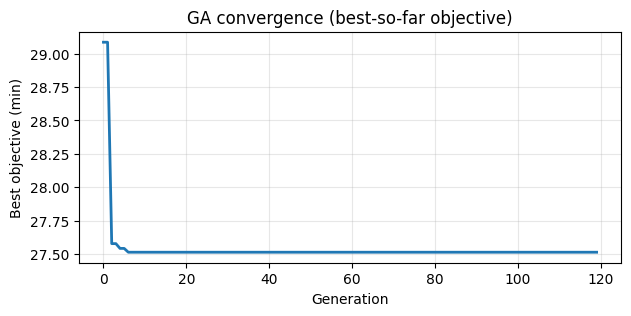

In [4]:
# ----------------------------
# Plot GA convergence
# ----------------------------
# `history[g]` stores the best objective found up to generation g.

plt.figure(figsize=(7, 3))
plt.plot(history, lw=2)
plt.title("GA convergence (best-so-far objective)")
plt.xlabel("Generation")
plt.ylabel("Best objective (min)")
plt.grid(True, alpha=0.3)
plt.show()

## Interpreting the best plan

The plot below shows the crane movement implied by the best solution.

- Each arrow is a crane move to a container (single) or to a center point (dual).
- If you see many short arrows, the solution is effectively clustering nearby lifts.


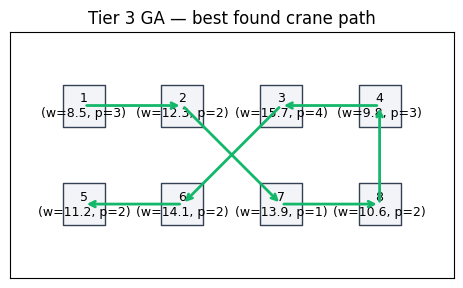

In [5]:
# ----------------------------
# Visualize the best plan
# ----------------------------
# We draw:
# - a 2x4 grid
# - container labels
# - arrows for the crane's visited targets

fig, ax = plt.subplots(figsize=(7, 3.2))

# Draw grid
for r in [0, 1]:
    for c in [0, 1, 2, 3]:
        ax.scatter([c], [-r], s=900, marker="s", facecolor="#F2F4F7", edgecolor="#344054")

# Draw container labels
for cont in containers:
    x, y = cont.rc[1], -cont.rc[0]
    ax.text(x, y, f"{cont.id}\n(w={cont.weight}, p={cont.priority})", ha="center", va="center", fontsize=9)

# Build path: start -> each step target
path = [(START_RC[1], -START_RC[0])]
for step in best_plan:
    rr, cc = step["to"]
    path.append((cc, -rr))

# Draw arrows
for (x1, y1), (x2, y2) in zip(path[:-1], path[1:]):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=2, color="#12B76A"),
    )

ax.set_title("Tier 3 GA — best found crane path")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-0.75, 3.75)
ax.set_ylim(-1.75, 0.75)
ax.set_aspect("equal")

plt.show()

## Additional operational visualizations (logistics-focused)

The path plot is useful, but operationally we also want to see:

- step-by-step durations (where we spend time)
- cumulative completion time
- a simple timeline (Gantt-like view)

Below we derive these directly from the best plan found by the GA.

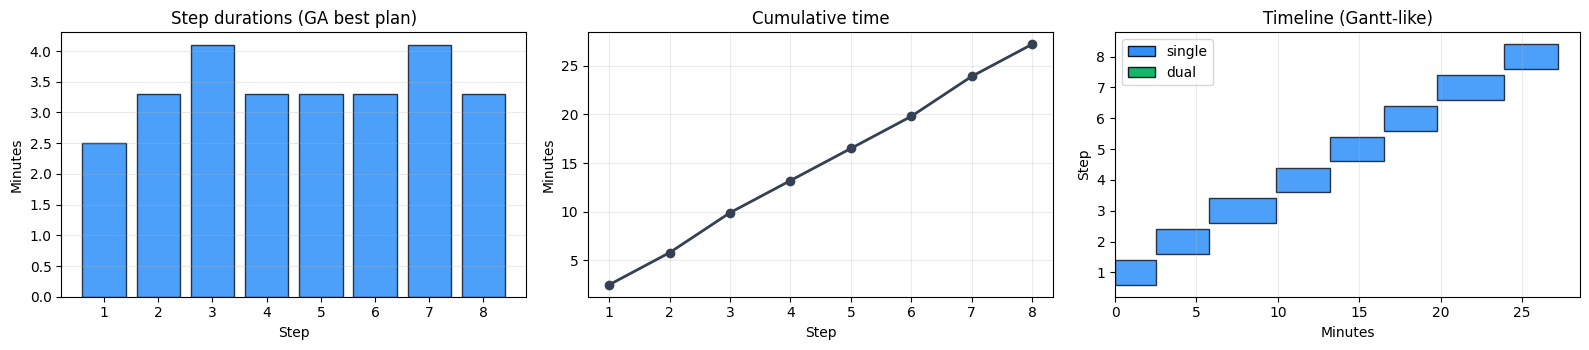

In [6]:
# ----------------------------
# Operational visualizations from the GA best plan
# ----------------------------
# The GA plan is a list of steps with:
# - type: 'single' or 'dual'
# - to: target coordinate (rc) or center coordinate
# - step_time: total time for that step
#
# We'll convert it into a table and plot:
# - step durations
# - cumulative time
# - Gantt-like timeline

vis = pd.DataFrame(best_plan).copy()
vis.index = np.arange(1, len(vis) + 1)
vis["step"] = vis.index.astype(int)

# Cumulative time after each step
vis["cum_time"] = vis["step_time"].cumsum()

# Start time for each step
vis["start_time"] = vis["cum_time"] - vis["step_time"]

# Color by step type
color_map = {"single": "#2E90FA", "dual": "#12B76A"}
colors = [color_map[t] for t in vis["type"].tolist()]

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))

# (1) Step durations
axes[0].bar(vis["step"], vis["step_time"], color=colors, edgecolor="#101828", alpha=0.85)
axes[0].set_title("Step durations (GA best plan)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Minutes")
axes[0].grid(True, axis="y", alpha=0.25)

# (2) Cumulative time
axes[1].plot(vis["step"], vis["cum_time"], marker="o", lw=2, color="#344054")
axes[1].set_title("Cumulative time")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Minutes")
axes[1].grid(True, alpha=0.25)

# (3) Timeline / Gantt-like
axes[2].barh(
    y=vis["step"],
    width=vis["step_time"],
    left=vis["start_time"],
    color=colors,
    edgecolor="#101828",
    alpha=0.85,
)
axes[2].set_title("Timeline (Gantt-like)")
axes[2].set_xlabel("Minutes")
axes[2].set_ylabel("Step")
axes[2].grid(True, axis="x", alpha=0.25)

# Legend
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=color_map["single"], edgecolor="#101828", label="single"),
    Patch(facecolor=color_map["dual"], edgecolor="#101828", label="dual"),
]
axes[2].legend(handles=legend_handles, loc="best")

plt.tight_layout()
plt.show()

## Why this Tier exists vs earlier Tiers (comparison)

### Why Tier 3 exists (vs Tier 1–2)

Tier 1 (DP) is optimal but can become infeasible as the instance grows. Tier 2 (greedy heuristic) is fast, but can be short-sighted.

Tier 3 exists to offer a middle ground:

- explore a much larger search space than greedy
- without requiring the exponential state enumeration of DP

A genetic algorithm (GA) can often find **very strong** solutions for hard sequencing problems, given enough iterations.

### Advantages vs Tier 1 (DP)

- Scales to larger problems (you can control runtime via population size / generations)
- Flexible: objective function can include many real-world details

### Advantages vs Tier 2 (greedy)

- Less short-sighted: can escape local choices by mutation/crossover
- Often finds better solutions if you allow more compute time

### Disadvantages

- Still not guaranteed optimal
- Requires parameter tuning (population size, mutation rate, generations)
- Runtime is higher than greedy (but you can cap it)

### When to use Tier 3

- You can afford some compute time (seconds/minutes)
- You want higher quality than a simple heuristic
- You have additional constraints/objectives and want a flexible optimizer
